# German houseing market analysis

## Problem statement:
The main goal of this project is to predict the base rent of apartments across Germany.
Such price prediction can help rental platforms understand the housing market and factors that affect rent prices, and finally, provide fair pricings to help their customers make better, data-driven decisions.

## Data:
1. Apartment data
    <br> The data is acquired from Kaggle and is a collection of rental offfers. The data was scrapped from Immoscout23 - the biggest real eastate platform in Germany (https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany/data)
2. Household income data
3. Postleitzahlen data
    <br>The dataset was sourced from github - (https://github.com/tdudek/de-plz-geojson/blob/master/plz-5stellig.geojson)

To ensure temporal consisistency in the project, all the datasets were chosen from the same reference period - around year 2019. 

## Fairness question:
The apartment listings data, especially the prices, are very likely to be biased so it is crucial to keep the bias awarness during analysis and conclusions.

Github link: 



IDEAS: 
- avaliable offers VS price -> see if lower demand means lower proces
python decorator
session state -> 

### This notebook has been divided into 2 followng chapters:
1. Exploratory Data Analysis.
2. Data Preprocessing: cleaning and feature engineering.

In [113]:
import pandas as pd
import geopandas as gpd

## Reading the data into data frames

In [ ]:
PATH = '/Users/zuzakutowska/Desktop/data_visualisation/final_project/data'
df = pd.read_csv(PATH + '/immo_data.csv')
df_plz = gpd.read_file(PATH + '/plz-5stellig.geojson')
# df_inc = 

# Chapter 1: Exploratory Data Analysis

This chapter focuses on exploring and deeply understanding the raw dataset.

To examine the Apartmetn datset the following steps were taken:
1. Display a sample of the data.
2. Examine missing values and show data type.
3. Showing initial descriptive statistics (initial check for outliers).
4. Examining categorical features and their unique values (needed later for encoding/mapping).

The goal after this chapter is to:
- Prepare a plan for cleaning the Apartment data (missing values and outliers).
- Choose what features are irrelevant and can be droppped.
- Choose a tactic for enxoding/mapping categorial features to lesses the number of unique values.

### Sample of Apartment dataset

In [115]:
print(f'The dataset has the following shape: {df.shape}')
print(' - '*50)
print(df.info())
print(' - '*50)

print(f'Data sample: {df.head()}')
with pd.option_context('display.max_columns', None):
    display(df.sample(5))

The dataset has the following shape: (268850, 49)
 -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  - 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268850 entries, 0 to 268849
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   regio1                    268850 non-null  object 
 1   serviceCharge             261941 non-null  float64
 2   heatingType               223994 non-null  object 
 3   telekomTvOffer            236231 non-null  object 
 4   telekomHybridUploadSpeed  45020 non-null   float64
 5   newlyConst                268850 non-null  bool   
 6   balcony                   268850 non-null  bool   
 7   picturecount              268850 non-null  int64  
 8   pricetrend                267018 non-null  float64
 9   telekomUploadSpeed        235492 non-null  float64
 10  totalRent  

,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,scoutId,noParkSpaces,firingTypes,hasKitchen,geo_bln,cellar,yearConstructedRange,baseRent,houseNumber,livingSpace,geo_krs,condition,interiorQual,petsAllowed,street,streetPlain,lift,baseRentRange,typeOfFlat,geo_plz,noRooms,thermalChar,floor,numberOfFloors,noRoomsRange,garden,livingSpaceRange,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
77347,Hessen,220.0,central_heating,NaN,NaN,False,True,18,2.75,NaN,1470.0,1959.0,110723220,NaN,natural_gas_light,True,Hessen,True,2.0,1250.0,12,96.00,Wiesbaden,well_kept,sophisticated,negotiable,Thomaestr,Thomaestr,False,7,apartment,65189,3.0,110.3,1.0,3.0,3,False,4,Wiesbaden,Nordost,Diese helle und gut geschnittene 3-Zimmerwohnu...,Die Wohnung wurde im Jahr 2016 kernsaniert.\n\...,NaN,NaN,2016.0,NaN,NaN,May19
29157,Nordrhein_Westfalen,130.0,central_heating,ONE_YEAR_FREE,NaN,False,True,11,3.85,40.0,550.0,1970.0,109986112,NaN,gas,True,Nordrhein_Westfalen,True,2.0,420.0,NaN,70.00,Herford_Kreis,NaN,NaN,no,no_information,NaN,False,3,apartment,32049,3.0,136.6,1.0,NaN,3,False,3,Herford_Kreis,Herford,Gepflegte 3-Zimmer-Wohnung in einem Haus mit 6...,NaN,NaN,E,NaN,NaN,NaN,May19
129584,Nordrhein_Westfalen,115.0,central_heating,ONE_YEAR_FREE,NaN,False,False,8,1.92,40.0,572.0,1953.0,112064442,NaN,natural_gas_light,False,Nordrhein_Westfalen,False,2.0,377.0,63,75.32,Gelsenkirchen,NaN,normal,negotiable,Wanner Str.,Wanner_Str.,False,2,apartment,45888,2.5,NaN,2.0,4.0,2,False,3,Gelsenkirchen,Bulmke_Hüllen,Die von uns angebotene Wohnung liegt im 2. OG ...,- renoviert\n- Gäste-WC\n- Tageslichtbad mit B...,80.0,NaN,NaN,NaN,NaN,Oct19
158563,Nordrhein_Westfalen,350.0,floor_heating,ONE_YEAR_FREE,10.0,False,True,16,4.67,10.0,1990.0,1982.0,78164908,1.0,NaN,True,Nordrhein_Westfalen,True,4.0,1640.0,NaN,136.00,Düsseldorf,NaN,NaN,no,no_information,NaN,False,8,maisonette,40474,3.0,NaN,2.0,2.0,3,False,6,Düsseldorf,Golzheim,Die Mietwohnung befindet sich in bester Lage\r...,NaN,NaN,NaN,NaN,NaN,NaN,Feb20
179130,Nordrhein_Westfalen,230.0,central_heating,ONE_YEAR_FREE,NaN,True,True,10,2.66,40.0,1330.0,2019.0,113537941,NaN,gas,False,Nordrhein_Westfalen,True,9.0,1100.0,4,114.00,Remscheid,first_time_use,sophisticated,negotiable,Raiffeisenstra&szlig;e,Raiffeisenstraße,True,7,apartment,42897,4.0,NaN,2.0,3.0,4,False,5,Remscheid,Bergisch_Born,Neubau in Bergisch-Born mit Aufzug .Tiefgarage...,Alles neu.,NaN,NaN,2019.0,NaN,NaN,Feb20


### Missing valuess in Apartment dataset and data types

To put the number of missing values into perspective, I calculated the percentage of missing values in the whole set (268,850 rows) for each feature.

In [116]:
row_count = df.shape[0]

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().sum() / row_count * 100,
    "Data type": df.dtypes
})

print(f'Missing values per column (out of {row_count} rows):')
print(missing_values.sort_values(by='Missing %', ascending=False))

Missing values per column (out of 268850 rows):
                          Missing Count  Missing % Data type
telekomHybridUploadSpeed         223830  83.254603   float64
electricityKwhPrice              222004  82.575414   float64
electricityBasePrice             222004  82.575414   float64
energyEfficiencyClass            191063  71.066766    object
lastRefurbish                    188139  69.979171   float64
heatingCosts                     183332  68.191185   float64
noParkSpaces                     175798  65.388879   float64
petsAllowed                      114573  42.615957    object
interiorQual                     112665  41.906267    object
thermalChar                      106506  39.615399   float64
numberOfFloors                    97732  36.351869   float64
houseNumber                       71018  26.415473    object
streetPlain                       71013  26.413614    object
condition                         68489  25.474800    object
yearConstructed                   570

### Inital descriptive statisctics for Apartemnt dataset

In [117]:
with pd.option_context('display.max_columns', None):
    display(df.describe())

,serviceCharge,telekomHybridUploadSpeed,picturecount,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,scoutId,noParkSpaces,yearConstructedRange,baseRent,livingSpace,baseRentRange,geo_plz,noRooms,thermalChar,floor,numberOfFloors,noRoomsRange,livingSpaceRange,heatingCosts,lastRefurbish,electricityBasePrice,electricityKwhPrice
count,261941.000000,45020.0,268850.000000,267018.000000,235492.000000,2.283330e+05,211805.000000,2.688500e+05,93052.000000,211805.000000,2.688500e+05,268850.000000,268850.000000,268850.000000,268850.000000,162344.000000,217541.000000,171118.000000,268850.000000,268850.000000,85518.000000,80711.000000,46846.000000,46846.000000
mean,151.206113,10.0,9.791958,3.389001,28.804928,9.013315e+02,1966.400590,1.069697e+08,1.327634,3.714544,6.941294e+02,74.355548,3.765256,37283.022235,2.641261,114.749533,2.122405,3.572319,2.571542,3.070790,76.990866,2013.904536,89.113612,0.199769
std,308.295790,0.0,6.408399,1.964874,16.337151,3.323833e+04,46.992207,1.250093e+07,8.361403,2.738134,1.953602e+04,254.759208,2.214357,27798.037296,2.633440,61.653663,3.634934,6.375496,0.937594,1.407127,147.716278,10.963125,5.395805,0.009667
min,0.000000,10.0,0.000000,-12.330000,1.000000,0.000000e+00,1000.000000,2.887174e+07,0.000000,1.000000,0.000000e+00,0.000000,1.000000,852.000000,1.000000,0.100000,-1.000000,0.000000,1.000000,1.000000,0.000000,1015.000000,71.430000,0.170500
25%,95.000000,10.0,6.000000,2.000000,10.000000,4.698000e+02,1950.000000,1.066910e+08,1.000000,1.000000,3.380000e+02,54.000000,2.000000,9128.000000,2.000000,79.000000,1.000000,2.000000,2.000000,2.000000,54.000000,2012.000000,90.760000,0.191500
50%,135.000000,10.0,9.000000,3.390000,40.000000,6.500000e+02,1973.000000,1.111584e+08,1.000000,3.000000,4.900000e+02,67.320000,3.000000,38667.000000,3.000000,107.000000,2.000000,3.000000,3.000000,3.000000,70.000000,2017.000000,90.760000,0.198500
75%,190.000000,10.0,13.000000,4.570000,40.000000,9.850000e+02,1996.000000,1.137688e+08,1.000000,5.000000,7.990000e+02,87.000000,5.000000,57072.000000,3.000000,140.300000,3.000000,4.000000,3.000000,4.000000,90.000000,2019.000000,90.760000,0.205500
max,146118.000000,10.0,121.000000,14.920000,100.000000,1.575154e+07,2090.000000,1.157117e+08,2241.000000,9.000000,9.999999e+06,111111.000000,9.000000,99998.000000,999.990000,1996.000000,999.000000,999.000000,5.000000,7.000000,12613.000000,2919.000000,90.760000,0.227600


array([[<Axes: title={'center': 'serviceCharge'}>,
        <Axes: title={'center': 'telekomHybridUploadSpeed'}>,
        <Axes: title={'center': 'picturecount'}>,
        <Axes: title={'center': 'pricetrend'}>,
        <Axes: title={'center': 'telekomUploadSpeed'}>],
       [<Axes: title={'center': 'totalRent'}>,
        <Axes: title={'center': 'yearConstructed'}>,
        <Axes: title={'center': 'scoutId'}>,
        <Axes: title={'center': 'noParkSpaces'}>,
        <Axes: title={'center': 'yearConstructedRange'}>],
       [<Axes: title={'center': 'baseRent'}>,
        <Axes: title={'center': 'livingSpace'}>,
        <Axes: title={'center': 'baseRentRange'}>,
        <Axes: title={'center': 'geo_plz'}>,
        <Axes: title={'center': 'noRooms'}>],
       [<Axes: title={'center': 'thermalChar'}>,
        <Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'numberOfFloors'}>,
        <Axes: title={'center': 'noRoomsRange'}>,
        <Axes: title={'center': 'livingSpaceRan

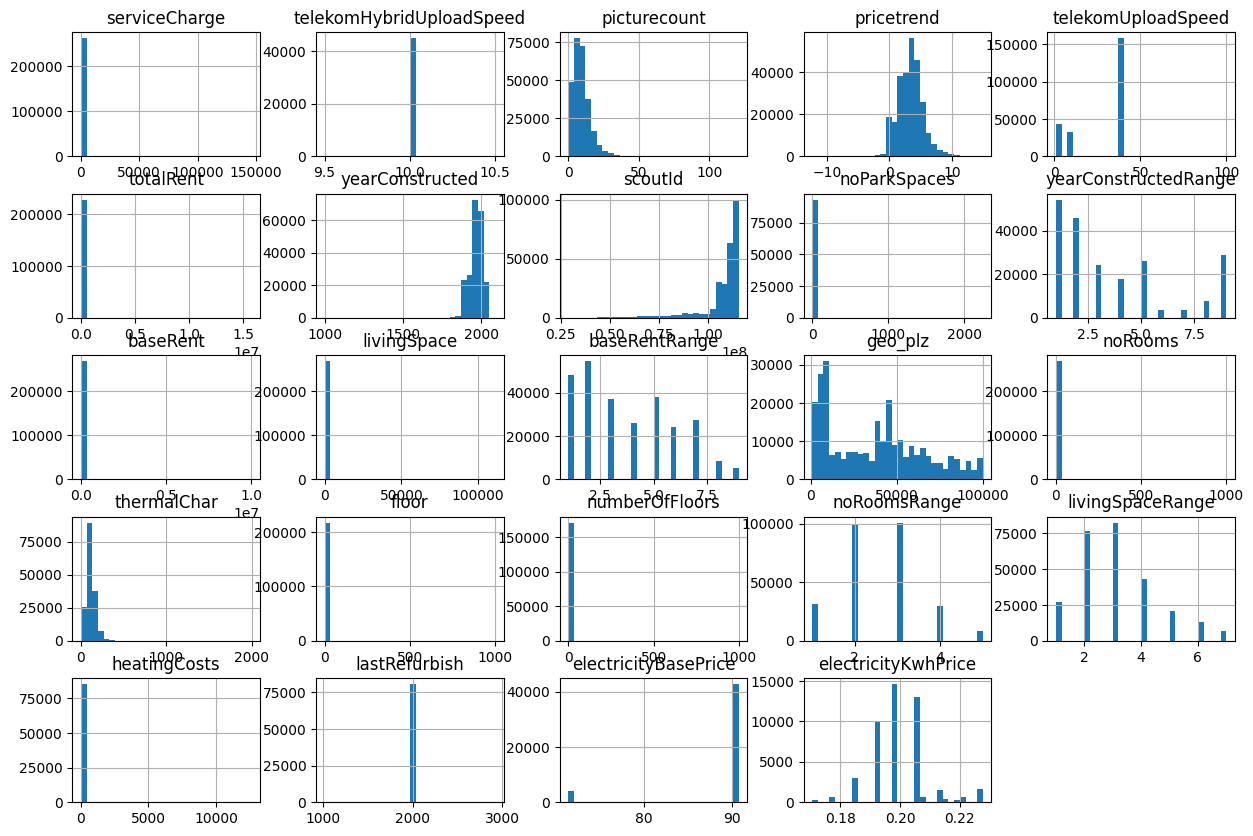

In [118]:
df.hist(bins=30, figsize=(15, 10))

### Checking for outliers in Apartment data

Based on the intial descriptive statistics I can see which features are problematic, and for those I am displaying the number of values that are likely to be outliers and calculating the percentage of them in the whole dataset. 

In [119]:
outlier_counts = {
    "noParkSpaces": (df['noParkSpaces'] > 10).sum(),
    "numberOfFloors": (df['numberOfFloors'] > 50).sum(),
    "yearConstructed_low": (df['yearConstructed'] < 1800).sum(),
    "yearConstructed_high": (df['yearConstructed'] > 2025).sum(),
    "noRooms": (df['noRooms'] > 10).sum(),
    "livingSpace_low": (df['livingSpace'] <= 0).sum(),
    "livingSpace_high": (df['livingSpace'] > 500).sum(),
    "baseRent_low": (df['baseRent'] <= 0).sum(),
    "baseRent_high": (df['baseRent'] > 20000).sum()
}

outlier_counts = pd.Series(outlier_counts, name="Outlier Count")
print(outlier_counts)
print("Total outliers:", outlier_counts.sum())
print("Total rows in dataset:", len(df))
print("Percentage of outliers:", f"{(outlier_counts.sum() / len(df) * 100):.4f}%")

noParkSpaces            560
numberOfFloors           20
yearConstructed_low     888
yearConstructed_high      5
noRooms                  56
livingSpace_low          75
livingSpace_high         25
baseRent_low             89
baseRent_high             8
Name: Outlier Count, dtype: int64
Total outliers: 1726
Total rows in dataset: 268850
Percentage of outliers: 0.6420%


### Examining categorical features and their unique values



In [120]:
print(f'Conditions: {df["condition"].unique()}')
print(f'Interior quality: {df["interiorQual"].unique()}')
print(f'Firing types: {df["firingTypes"].unique()}')
print(f'Types of flats: {df["typeOfFlat"].unique()}')

Conditions: ['well_kept' 'refurbished' 'first_time_use' nan 'fully_renovated'
 'mint_condition' 'first_time_use_after_refurbishment' 'modernized'
 'negotiable' 'need_of_renovation' 'ripe_for_demolition']
Interior quality: ['normal' 'sophisticated' nan 'simple' 'luxury']
Firing types: ['oil' 'gas' nan 'district_heating' 'gas:electricity' 'electricity'
 'pellet_heating' 'natural_gas_light'
 'combined_heat_and_power_fossil_fuels' 'district_heating:local_heating'
 'steam_district_heating' 'natural_gas_heavy' 'gas:district_heating'
 'solar_heating:gas' 'environmental_thermal_energy' 'local_heating'
 'gas:natural_gas_light' 'geothermal'
 'combined_heat_and_power_regenerative_energy' 'heat_supply'
 'oil:electricity' 'solar_heating' 'geothermal:solar_heating'
 'district_heating:electricity' 'liquid_gas' 'wood' 'hydro_energy'
 'combined_heat_and_power_renewable_energy' 'coal'
 'gas:steam_district_heating' 'bio_energy'
 'gas:environmental_thermal_energy' 'wood_chips' 'gas:oil'
 'solar_heating:wo

### Checking for duplicates

In [121]:
df.duplicated().sum()

np.int64(0)

### Preprocessing plan
(more details for each feature in the later steps in the next chapter)

-  **Drop features (too many NAs / not relevant enough / high risk or mistakes):** 

    'telekomHybridUploadSpeed', 'electricityKwhPrice', 'electricityBasePrice',
    'energyEfficiencyClass', 'heatingCosts', 'houseNumber', 'streetPlain',
    'yearConstructedRange', 'facilities', 'floor', 'heatingType',
    'telekomUploadSpeed', 'telekomTvOffer', 'pricetrend', 'regio3', 'regio2', 'livingSpaceRange', 'noRoomsRange', 'regio1', 'baseRentRange', 'street', 'geo_bln', 'scoutId', 'picturecount', 'date', 'totalRent', 'description'

- **Clean outliers:** 

    livingSpace, noRooms, baseRent, geo_krs, geo_plz

- **Drop duplicates**

- **Impute + flags(for missing):** 

    numberOfFloors (median by geo_krs + _missing), <br>thermalChar (median by yearConstructed + _missing), <br>
    serviceCharge (0), petsAllowed (“missing”), <br>
    interiorQual (“normal” + _missing)

- **Engineer new features:**   

    lastRefurbish → yearsSinceRefurbish (int) + wasRefurbished (0/1), then drop lastRefurbish <br>
    firingTypes/typeOfFlat/condition → normalized categories <br>



# Chapter 2: Data preprocessing: cleaning and feature engineering

The puprose of this chapter is to transform the messy data info a usable set ready for analysis.

## Droping columns
Dropping columns that have too many missing values OR the feature is not relevant OR there is a high risk of spelling mistakes.

In [122]:
drop_cols = [
    'telekomHybridUploadSpeed', 'electricityKwhPrice', 'electricityBasePrice',
    'energyEfficiencyClass', 'heatingCosts', 'houseNumber', 'streetPlain',
    'yearConstructedRange', 'facilities', 'floor', 'heatingType', 'firingTypes',
    'telekomUploadSpeed', 'telekomTvOffer', 'pricetrend', 'regio3', 'regio2',
    'livingSpaceRange', 'noRoomsRange', 'regio1', 'baseRentRange', 'street',
    'geo_bln', 'scoutId', 'picturecount', 'date', 'totalRent', 'description',
    'serviceCharge'
]

df.drop(columns=drop_cols, inplace=True)

## Handling outliers
During the EDA I  noticed some instances of outliers. To handle them for the left numerical features, I first check the count of irrational values and check what percentage of the train set they are.

Since the result I got was low - 0.64% - I decided to simply drop these rows.

In [123]:
df = df[(df['baseRent'] > 0) & (df['baseRent'] < 20000)] 
df = df[(df['livingSpace'] > 0) & (df['livingSpace'] < 500)]
df = df[(df['noParkSpaces'] <= 10)]
df = df[(df['noRooms'] <= 10)]
df = df[(df['yearConstructed'] >= 1800) & (df['yearConstructed'] <= 2025)]


## Dropping duplicates

In [124]:
df = df.drop_duplicates()

## Feature engineering on ordinal and cathergorical fetaures

During the EDA I have found many issues with the ordinal and cathegorical features of the dataset.
To keep the notebook organised I will be working on specific features one by one.

**'petsAllowed' feature** -> changing all NAs to "missing" to keep 4 options: "no", "yes", "negotiable", "missing" and casting the datatype to category

In [125]:
pets = pd.CategoricalDtype(categories=['no', 'yes', 'negotiable', 'missing'])
df['petsAllowed'] = df['petsAllowed'].fillna('missing').astype(pets)

**'interiorQual' feature** -> changing all NAs to "normal" (to keep the ordinal relationship: simple < normal < sophisticated < luxury) while creating a new binary feature interiorQual_missing to flag the NAs 

In [126]:
interior = pd.CategoricalDtype(categories=['simple', 'normal', 'sophisticated', 'luxury'], ordered=True)
df['interiorQual'] = df['interiorQual'].fillna('normal').astype(interior)

**'yearConstructed' feature** -> changing all NAs to a median from a given region (geo_krs) and casting the data type to integer

In [127]:
median_by_krs = df.groupby('geo_krs')['yearConstructed'].median()
df['yearConstructed'] = df['yearConstructed'].fillna(df['geo_krs'].map(median_by_krs)).astype(int)

**'thermalChar' feature** -> changing all NAs to a median from a given time of building (by decades)

In [128]:
decades = (df['yearConstructed'] //10) * 10
thermal_by_year = df.groupby(decades)['thermalChar'].median().astype(int)
global_median = df['thermalChar'].median() # observed some NAs in thermalChar so there was no maping for those
df['thermalChar'] = df['yearConstructed'].map(thermal_by_year).fillna(global_median).astype(int)

**'numberOfFloors' feature** -> changing all NAs to median by region(geo_krs)

In [129]:
floors_by_region = df.groupby('geo_krs')['numberOfFloors'].median()
df['numberOfFloors'] = df['geo_krs'].map(floors_by_region).astype(int)

**'condition' feature** ->
considering the 25% of missing values I am creating a new category 'unknown' and  creating a dictionary to normalise the categories to (bad < needs_renovation < unknown < good < refurbished < mint < new) keeping the ordinality and casting the datatype to category

In [130]:
condition_mapping = {
    'ripe_for_demolition': 'bad',
    'need_of_renovation': 'needs_renovation',
    'well_kept': 'good',
    'refurbished': 'refurbished',
    'fully_renovated': 'refurbished',
    'modernized': 'refurbished',
    'mint_condition': 'mint',
    'first_time_use': 'new',
}

df['condition'] = df['condition'].map(condition_mapping).fillna('unknown').astype('category')

**'typeOfFlat' feature** -> creating a dictionary and simplifying the categories, casting to data type category

In [131]:
type_mapping = {
    'apartment': 'apartment',
    'loft': 'apartment',
    'ground_floor': 'ground',
    'raised_ground_floor': 'ground',
    'half_basement': 'ground',
    'roof_storey': 'top_floor',
    'penthouse': 'penthouse',
    'maisonette': 'maisonette',
    'terraced_flat': 'terraced',
    'other': 'other',
}

df['typeOfFlat'] = df['typeOfFlat'].map(type_mapping).fillna('other').astype('category')

**'noRooms' feature** -> I noticed some fractions so rounding the values and changing the data type to integer

In [132]:
df['noRooms'] = df['noRooms'].round(0).astype(int)

**'noParkSpaces' feature** -> changing all NAs to new value "0" and casting to integer (it is a float now)

In [133]:
df['noParkSpaces'] = df['noParkSpaces'].fillna(0).round(0).astype(int)

## Adding a new location feature

This new feature will serve as a key when joining the apartment dataset with the geo location data and the household income data. 

For the visualisation I want to keep two options for tracting regions:
- by all 5 digits of the PLZ code - for more detailed maps (for showing a speciifc city) - this approach gives 7634 regions
- by the first 2 digits of the PLZ code - for visualisations of the whole contry - this approach gives 90 regions

During creating this new features I came accross two bugs: 
- the initial geo_plz feature was set to int datatype and this cause the zeros at the begining of the postal codes to disapear (there were 75,353 entires with 4 digits) -> need to fill in the zeros and change the data type into a string
- there is 3 entries with only 3 digits and those are incorrect values -> values should be dropped

In [134]:
print(df['geo_plz'].astype(str).str.len().value_counts())
df['geo_plz'] = df['geo_plz'].astype(str).str.zfill(5)
df = df[df['geo_plz'].str.len() == 5]

geo_plz
5    60821
4    13610
Name: count, dtype: int64


### Creating the 2 digits postal code and renaming the 5 digits postal code column

In [135]:
df['plz_2'] = df['geo_plz'].astype(str).str[:2]
df = df.rename(columns={'geo_plz': 'plz_5'})

### Saving the cleaned apartment data
The apartment dataset has been preprocessed and is now ready for analysis. I am saving it into a parquet file to reduce the file size, speed up the visualisations, and preserve the datatypes.

In [136]:
df.to_parquet(PATH + '/apartments_clean.parquet', index=False)

## Exploring the Postleitzahlen dataset

In [137]:
df_plz.head()


,plz,note,qkm,einwohner,geometry
0,01067,01067 Dresden,6.866862,11957,"POLYGON ((13.68689 51.06395, 13.69794 51.06588..."
1,01069,01069 Dresden,5.352387,25491,"MULTIPOLYGON (((13.72635 51.02186, 13.73031 51..."
2,01097,01097 Dresden,3.276896,14811,"POLYGON ((13.72548 51.0686, 13.73565 51.06995,..."
3,01099,01099 Dresden,58.523263,28004,"POLYGON ((13.74218 51.08979, 13.75103 51.08672..."
4,01108,01108 Dresden,16.447222,5876,"POLYGON ((13.76543 51.17491, 13.77167 51.17421..."


In [138]:
df_plz.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   plz        8173 non-null   object  
 1   note       8173 non-null   object  
 2   qkm        8173 non-null   float64 
 3   einwohner  8173 non-null   int32   
 4   geometry   8173 non-null   geometry
dtypes: float64(1), geometry(1), int32(1), object(2)
memory usage: 287.5+ KB


For a smoother join with the apartment data I am adding a new feature with the first 2 digits of the postal code and renaming the features so they match the apartment dataset.

In [139]:
df_plz['plz_2'] = df_plz['plz'].astype(str).str[:2]
df_plz.rename(columns = {'plz': 'plz_5'}, inplace=True)

For the final step I am renaming the population column and dropping 'note' feature (ensuing normalisation standards across the database).

In [140]:
df_plz.rename(columns = {'einwohner': 'population'}, inplace=True)
df_plz.drop(columns = ['note'], inplace=True)

Finally, the preprocessed postal code datset is saved as a new file.

In [141]:
df_plz.to_file(PATH + '/plz_clean.geojson', driver='GeoJSON')

In [142]:
# df_inc = pd.read_csv(
#     path + '/income.csv',
#     sep=";",
#     encoding="latin1",
#     skiprows=7
# )

# df_inc.head()